**Table of contents**<a id='toc0_'></a>    
- [Simulation output 4 fluorophores with ET (and photobleaching)](#toc1_)    
  - [Data generation](#toc1_1_)    
    - [Simulation](#toc1_1_1_)    
    - [Save the data](#toc1_1_2_)    
  - [Data processing and visualization](#toc1_2_)    
    - [Read the data](#toc1_2_1_)    
    - [Post-processing](#toc1_2_2_)    
    - [Figure](#toc1_2_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Simulation output 4 fluorophores with ET (and photobleaching)](#toc0_)

In [1]:
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.simulation as si
import fluopy.prediction as pr
import fluopy.analysis as an
import fluopy.transitions as tr
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

for package in [bl, em, fcs_p, fl, fo, si, pr, an, tr, rt]:
    print(f"{package.__name__} version: {package.__version__}")

saving_at = r"D:\python_output\Chapter_I\1_9_multi_f_et_statistics"

fluopy.blinking version: 0.1.0
fluopy.emissions version: 0.1.0
fluopy.fcs version: 0.1.0
fluopy.fluorophores version: 0.1.0
fluopy.formulas version: 0.1.0
fluopy.simulation version: 0.1.0
fluopy.prediction version: 0.1.0
fluopy.analysis version: 0.1.0
fluopy.transitions version: 0.1.0
fluopy.routines version: 0.1.0


## <a id='toc1_1_'></a>[Data generation](#toc0_)

### <a id='toc1_1_1_'></a>[Simulation](#toc0_)

In [2]:
PARAMS_DSTORM = {
    "irradiance": 2.5,
    "wavelength": 640,
    "dstorm": True,
    "dstorm_parameters": {
        "reducing_agent": "mea",
        "concentration": 100,
        "ph": 7.5,
    },
    'energy_transfer_parameters': {'overwrite': {'off': [1e-5, 1]}, 
                                   'exclude': ['s0', 't1']},

}


fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=4, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=True,
    energy_transfer=True,
    **PARAMS_DSTORM,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
rng = np.random.default_rng(1)

simulation = si.Simulation(transition_set)
simulation.run(size=1e6, end_time=100, seed=rng, use_memmap=saving_at)

WARNING for line:         warnings.warn(
 Floating point precision error warning:
 The smallest safe increment is 1.42e-14.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1, 1, 1, 1]
 gives a probability of 1.47e-02 for a smaller increment to be drawn. 


In [46]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=4, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=True,
    energy_transfer=True,
    **rt.PARAMS_DSTORM,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
rng = np.random.default_rng(1)

simulation = si.Simulation(transition_set)
simulation.run(size=1e6, end_time=2000, seed=rng, use_memmap=saving_at)

KeyboardInterrupt: 

### <a id='toc1_1_2_'></a>[Save the data](#toc0_)

In [9]:
with open(saving_at + r"\transition_set.pkl", "wb") as f:
    pickle.dump(transition_set, f)
# the simulation is saved in the memmap file
# reading memmap files require shape
shape_state_series = simulation.state_series.shape
shape_transition_series = simulation.transition_series.shape
shape_time_series = simulation.time_series.shape
print(f"state_series shape: {shape_state_series}")
print(f"transition_series shape: {shape_transition_series}")
print(f"time_series shape: {shape_time_series}")

state_series shape: (4, 117163499)
transition_series shape: (117163498,)
time_series shape: (117163500,)


## <a id='toc1_2_'></a>[Data processing and visualization](#toc0_)

### <a id='toc1_2_1_'></a>[Read the data](#toc0_)

In [10]:
with open(saving_at + r"\transition_set.pkl", "rb") as f:
    transition_set = pickle.load(f)
simulation = si.Simulation(transition_set)
simulation.state_series = np.memmap(
    saving_at + r"\state_series",
    dtype=np.int8,
    mode="r",
    shape=shape_state_series,
)
simulation.transition_series = np.memmap(
    saving_at + r"\transition_series",
    dtype=np.uint32,
    mode="r",
    shape=shape_transition_series,
)
simulation.time_series = np.memmap(
    saving_at + r"\time_series",
    dtype=np.float64,
    mode="r",
    shape=shape_time_series,
)

### <a id='toc1_2_2_'></a>[Post-processing](#toc0_)

In [3]:
analysis = an.Analysis(simulation)

emis = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis.extract(simulation)
rt.emission_post_processing(emis, rng)

fcs = fcs_p.FCS(emis)
fcs.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)

blink = bl.Blinking(emis)

fluorophore 2 has reached the Markovian absorbing state SingleState.B
fluorophore 3 has reached the Markovian absorbing state SingleState.B


WARNING for line:             warnings.warn(
 if a fluorophore reaches its individual absorbing state, it has an absolute state and transition frequency of 1, but the lifetime is nan and the state occupation 0. 


### <a id='toc1_2_3_'></a>[Figure](#toc0_)

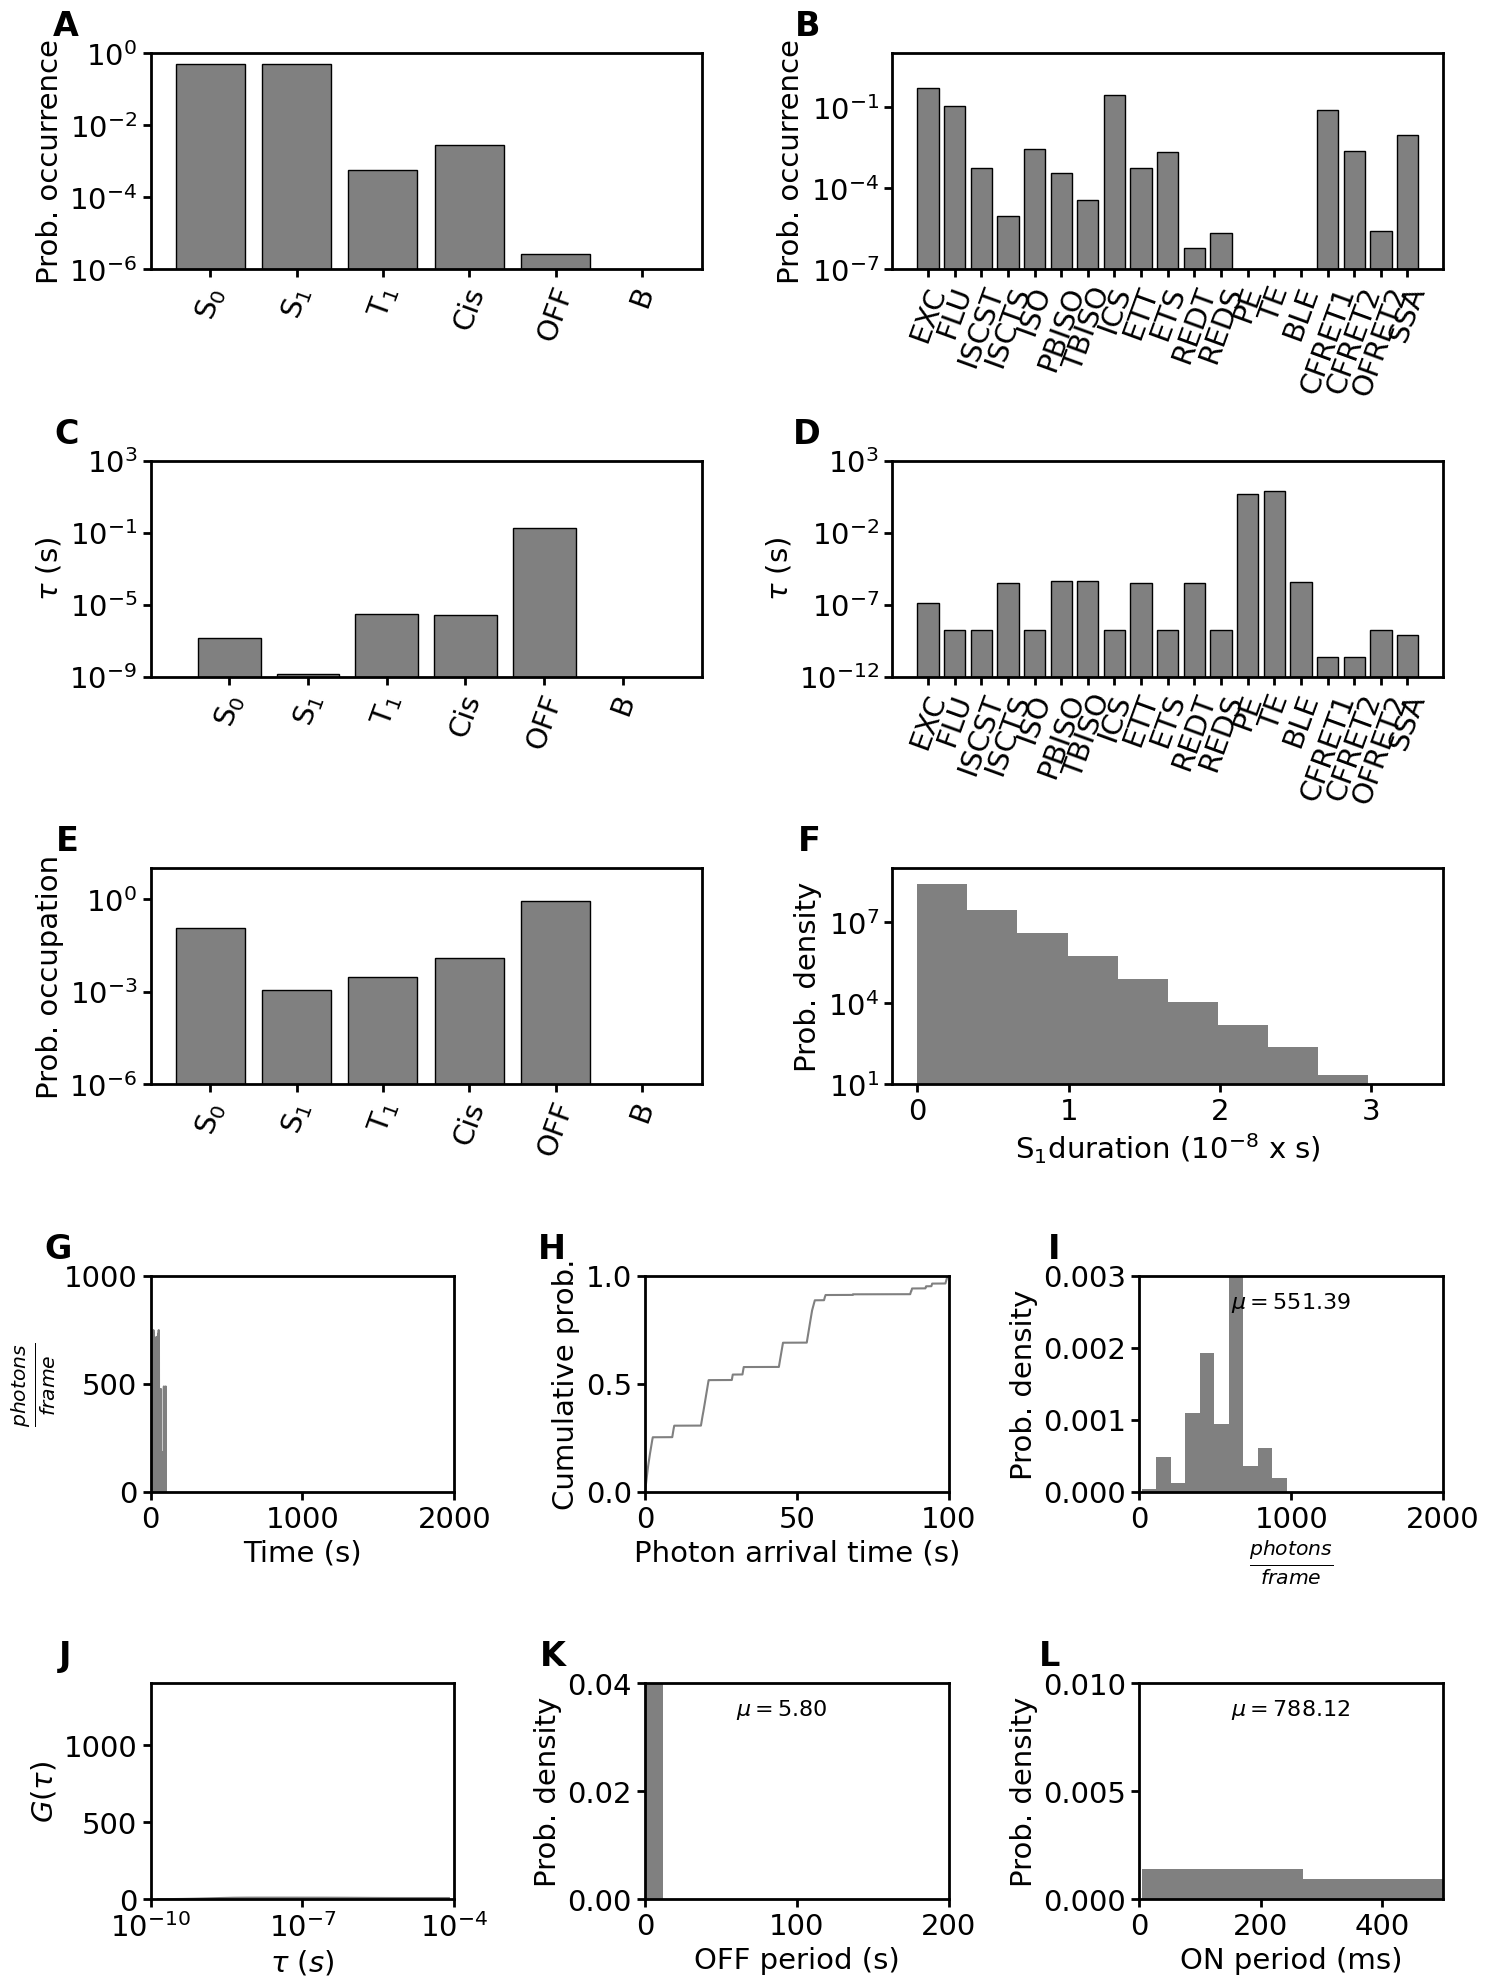

In [5]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(5, 6)
fig = plt.figure(figsize=(15, 20))
color = "grey"
analysis_plot_param = dict(legend=False, color=color)
ax = fig.add_subplot(gs[0, 0:3])
analysis.plot_frequency_states(ylim=[1e-6, 1e0], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[0, 3:])
analysis.plot_frequency_transitions(
    ylim=[1e-7, 1e1], axes=ax, diff_dist=False, **analysis_plot_param
)
ax = fig.add_subplot(gs[1, 0:3])
analysis.plot_mean_lifetimes(ylim=[1e-9, 1e3], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[1, 3:])
analysis.plot_mean_transition_times(
    ylim=[1e-12, 1e3], axes=ax, diff_dist=False, **analysis_plot_param
)
ax = fig.add_subplot(gs[2, 0:3])
analysis.plot_state_occupations(ylim=[1e-6, 1e1], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[2, 3:])
analysis.plot_lifetime_distributions(
    state_identity=1,
    axes=ax,
    fluorophore="cy5_dna",
    **analysis_plot_param,
    title=None,
    ylim=[1e1, 1e9],
    tick_style_x="sci"
)


ax = fig.add_subplot(gs[3, 0:2])
emis.plot_time_series(axes=ax, color=color, xlim=[0, 2000], ylim=[0, 1000])
ax = fig.add_subplot(gs[3, 2:4])
emis.plot_cumulative_events(axes=ax, color=color, xlim=[0, 100])
ax = fig.add_subplot(gs[3, 4:])
emis.plot_histogram(
    axes=ax, color=color, ylim=[0, 0.003], xlim=[0, 2000], display_mean=True
)


ax = fig.add_subplot(gs[4, 0:2])
fcs.plot(axes=ax, unit="s", color=color, title=None, xlim=[1e-10, 1e-4], ylim=[0, 1400])
ax = fig.add_subplot(gs[4, 2:4])
blink.plot(
    mode="off_histogram",
    axes=ax,
    as_time="s",
    color=color,
    xlim=[0, 200],
    ylim=[0, 0.04],
)
ax = fig.add_subplot(gs[4, 4:])
blink.plot(
    mode="on_histogram",
    axes=ax,
    as_time="ms",
    color=color,
    xlim=[0, 500],
    ylim=[0, 0.01],
)
axes = fig.get_axes()
for i, (axis, letter) in enumerate(
    zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"])
):
    offset = -0.13
    if i > 5:
        offset = -0.26
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()

fig.savefig(
    saving_at + r"\4_f_et_statistics.png", bbox_inches="tight", pad_inches=0.1, dpi=300
)